In [1]:
from scipy import stats
import matplotlib.pyplot as plt

from analysis_helpers import *

# Outline
NOTE: This notebook makes heavy use of user-defined helper functions. See analysis_helpers.py for more detail. 
All training and evaluation was done using instructor-provided starter code as is. This code has been removed to prevent academic dishonesty by current or future students of the course.

 1. Analyze training datasets for artifacts: SNLI and SNLI Par-Z datasets for artifacts. For each dataset:
    - For each word compute Z-score to test hypothesis: p_hat > 1/3
    - calculate % of words in vocabulary where we can reject null (i.e. % data artifacts)
    - Plot artifact statistics for both datasets
2. Reformat SNLI-hard dataset to HF expected JSON format
3. Evaluate ELECTRA-small models on single token examples
    - construct single token datasets from vocabs for SNLI and SNLI Par-Z datasets
    - compute delta p, average predicted model probability for each class
4. Fine tune ELECTRA-small models on SNLI and SNLI-datasets
    - Not shown here. Metrics taken from eval_metrics.json produced by running run.py in console

# 1. Analyze SNLI base and SNLI Par-Z

In [2]:
# import SNLI base dataset dataframe with all necessary statistics
df_snli = get_token_statistics('snli')

# select words + label where we can reject the null (of equal proportion)
pct_artifacts = len(df_snli[df_snli.is_artifact])/len(df_snli)
print(f'Percent artifacts: {pct_artifacts:.4f}')

550152it [01:12, 7624.03it/s]


Percent artifacts: 0.0364


In [3]:
# import SNLI Par-Z dataset as dataframe with all necessary statistics
df_zpar = get_token_statistics('training_data/snli_par-z.jsonl')

# select words + label where we can reject the null (of equal proportion)
pct_artifacts = len(df_zpar[df_zpar.is_artifact])/len(df_zpar)
print(f'Percent artifacts: {pct_artifacts:.4f}')

100%|██████████| 933085/933085 [01:10<00:00, 13264.08it/s]


Percent artifacts: 0.0198


### Plotting dataset artifacts

In [4]:
# format plotting data
val_vars= ['count_e','count_n','count_c','phat_e','phat_n','phat_c']
df_plot_base = df_snli.loc[:, val_vars].reset_index().rename(columns={'index':'word'})
df_plot_base = pd.wide_to_long(df_plot_base, stubnames=['count_', 'phat_'], i='word', j='group', suffix='\D+').reset_index()
df_plot_base = df_plot_base.merge(df_snli.is_artifact, how='left', right_index=True, left_on='word')

df_plot_parz = df_zpar.loc[:, val_vars].reset_index().rename(columns={'index':'word'})
df_plot_parz = pd.wide_to_long(df_plot_parz, stubnames=['count_', 'phat_'], i='word', j='group', suffix='\D+').reset_index()
df_plot_parz = df_plot_parz.merge(df_zpar.is_artifact, how='left', right_index=True, left_on='word')

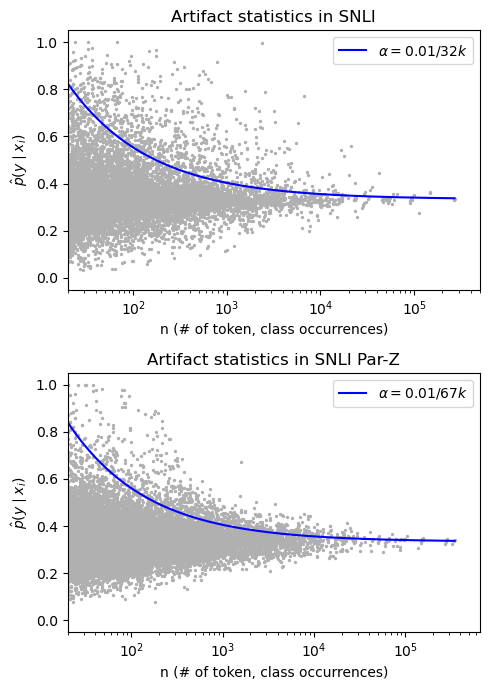

In [5]:
fig, axs = plt.subplots(2, figsize=(5,7))

# top plot: SNLI
axs[0].scatter(df_plot_base.count_, df_plot_base.phat_, s=2, c='#b0b0b0')
pcrit = 1 - (0.05 / len(df_snli))
zcrit = stats.norm.ppf(pcrit)
ns = np.logspace(np.log(20)/np.log(10), np.log(df_plot_base.count_.max()) / np.log(10), 1000)
crit_line =  1/3 + (1/np.sqrt(ns)) * (zcrit * np.sqrt(1/3 * 2/3))
axs[0].plot(ns, crit_line, linewidth=1.5, c='blue', label=r"$\alpha=0.01/32k$")
axs[0].set_title('Artifact statistics in SNLI')

# bottom plot: SNLI Par-Z
axs[1].scatter(df_plot_parz.count_, df_plot_parz.phat_, s=2, c='#b0b0b0')
pcrit = 1 - (0.05 / len(df_zpar))
zcrit = stats.norm.ppf(pcrit)
ns = np.logspace(np.log(20)/np.log(10), np.log(df_plot_parz.count_.max()) / np.log(10), 1000)
crit_line =  1/3 + (1/np.sqrt(ns)) * (zcrit * np.sqrt(1/3 * 2/3))
axs[1].plot(ns, crit_line, linewidth=1.5, c='blue',  label=r"$\alpha=0.01/67k$")
axs[1].set_title('Artifact statistics in SNLI Par-Z')

for ax in axs.flat:
    ax.legend()
    ax.set(ylabel=R'$\hat p(y \mid x_i)$', 
           xlabel='n (# of token, class occurrences)', 
           xscale='log',
           xlim=20)

plt.tight_layout()
plt.savefig('figures/training_data_comparison.png')
plt.show()

# Reformatting SNLI-hard dataset
Only needs to be run once!

In [ ]:
import json

lookup = {'entailment':0, 'neutral':1, 'contradiction':2}
output = open('data/snli_hard_formatted.jsonl', 'w')

with open('data/snli_1.0_test_hard.jsonl', 'r') as input:
    for line in input:
        ex = json.loads(line)
        formatted_ex = dict()
        formatted_ex['premise'] = ex['sentence1']
        formatted_ex['hypothesis'] = ex['sentence2']
        formatted_ex['label'] = lookup[ex['gold_label']]
        json.dump(formatted_ex, output)
output.close()

# 3. Analyze models on single token datasets

In [6]:
# partitioning words in SNLI dataset to calculate delta p
snli_partitions = get_partitioned_tokens(df_snli)

# create a synthetic dataset where each premise only has one token with an empty hypothesis and vice versa
create_single_token_dataset(list(snli_partitions.index), 'data/snli_base_single_token.json')

# unpack predictions on single token evaluation set
base_single_token_preds = unpack_predictions('final_output_base_base_st/eval_predictions.jsonl', snli_partitions)

In [7]:
# calculation delta p's for SNLI dataset
print('Single token evaluation dataset')
print('Average model predicted class probability')
for label in range(3):
    print(f'Class {label}: {(calc_delta_p(base_single_token_preds, label)):.4f}')

Single token evaluation dataset
Average model predicted class probability
Class 0: 0.3679
Class 1: 0.2305
Class 2: 0.3128


In [8]:
# partitioning words in SNLI Par-Z dataset to calculate delta p
zpar_partitions = get_partitioned_tokens(df_zpar)

# create a synthetic dataset where each premise only has one token with an empty hypothesis and vice versa
create_single_token_dataset(list(zpar_partitions.index), 'data/snli_parz_single_token.json')

# unpack predictions on single token evaluation set
parz_single_token_preds = unpack_predictions('final_output_parz_st/eval_predictions.jsonl', zpar_partitions)

In [9]:
# calculation delta p's for SNLI Par-Z dataset
print('Single token evaluation dataset')
print('Average model predicted class probability')
for label in range(3):
    print(f'Class {label}: {(calc_delta_p(parz_single_token_preds, label)):.4f}')

Single token evaluation dataset
Average model predicted class probability
Class 0: 0.3324
Class 1: 0.0739
Class 2: 0.1285
